In [6]:
from scipy.io import loadmat

data = loadmat(r"C:\Users\Luchitha\Documents\BCI\Hackathon\data\P1_post_training.mat")

print(data.keys())  # see variables inside

fs = float(data['fs'].squeeze())  # sampling frequency
print(f"Sampling Frequency: {fs} Hz")
y = data['y']  # labels
print(f"Labels shape: {y.shape}")
trig= data['trig']  # trigger information   trigger is the actual time when the stimulus was presented, and it is used to segment the EEG data into epochs corresponding to each stimulus presentation.  1 - left hand trigger , -1 - right hand trigger
print(f"Trigger shape: {trig.shape}")


dict_keys(['__header__', '__version__', '__globals__', 'fs', 'trig', 'y'])
Sampling Frequency: 256.0 Hz
Labels shape: (197343, 16)
Trigger shape: (197343, 1)


In [ ]:
import numpy as np

print("EEG data array y shape:", y.shape)
print("EEG data type:", y.dtype)
print("Trigger array trig shape:", trig.shape)
print("Trigger unique labels:", np.unique(trig))
print("First 20 trigger values:", trig.flatten()[:20])

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Prepare EEG data for MNE: RawArray expects shape (n_channels, n_times)
eeg = y
if eeg.ndim != 2:
    raise ValueError(f"Expected y to be 2D EEG data, got shape {eeg.shape}")

if eeg.shape[0] > eeg.shape[1]:
    eeg = eeg.T

n_channels, n_times = eeg.shape
ch_names = [f"EEG {i+1:03d}" for i in range(n_channels)]
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types='eeg')
raw = mne.io.RawArray(eeg, info)

print(raw)
print("Raw info channel count:", raw.info['nchan'])
print("Raw duration (s):", raw.times[-1])

labels = trig.flatten()
print("Labels shape:", labels.shape)
print("Unique labels:", np.unique(labels))

plt.figure(figsize=(14, 5))
for idx in range(min(4, n_channels)):
    offset = idx * np.max(np.abs(eeg)) * 2
    plt.plot(raw.times, eeg[idx] + offset, label=ch_names[idx])

plt.xlabel('Time (s)')
plt.title('EEG preview for first channels')
plt.yticks([])
plt.legend(loc='upper right', fontsize='small')
plt.show()

In [ ]:
# Convert trig into MNE events and epoch the EEG signal
labels = trig.flatten()
if labels.shape[0] != n_times:
    raise ValueError(f"Trigger length {labels.shape[0]} does not match EEG time samples {n_times}")

# Detect event onsets where label changes from 0 to non-zero (or first sample is non-zero)
onset_mask = np.concatenate(([labels[0] != 0], (labels[1:] != labels[:-1]) & (labels[1:] != 0)))
event_samples = np.flatnonzero(onset_mask)

event_codes = labels[event_samples]
# Map true labels to positive event IDs for MNE
event_id = {
    -1: 1,
     1: 2,
}

mne_events = np.column_stack((event_samples, np.zeros_like(event_samples, dtype=int), [event_id[int(code)] for code in event_codes]))
print(f"Detected {len(mne_events)} events")
print("Event ID mapping:", event_id)
print("First 10 events:\n", mne_events[:10])

# Epochs around events (customize tmin/tmax as needed)
tmin, tmax = -0.2, 8.0  # 200 ms before to 8000 ms after event onset
epochs = mne.Epochs(raw, mne_events, event_id=event_id, tmin=tmin, tmax=tmax, baseline=(None, 0), preload=True)

print(epochs)
print("Epochs per class:")
for name, code in event_id.items():
    print(name, len(epochs[name]))

# Plot the first epoch of each class as a sanity check
for label_name in epochs.event_id:
    if len(epochs[label_name]) > 0:
        epochs[label_name][0].plot(scalings='auto', show=False, title=f'First epoch for {label_name}')


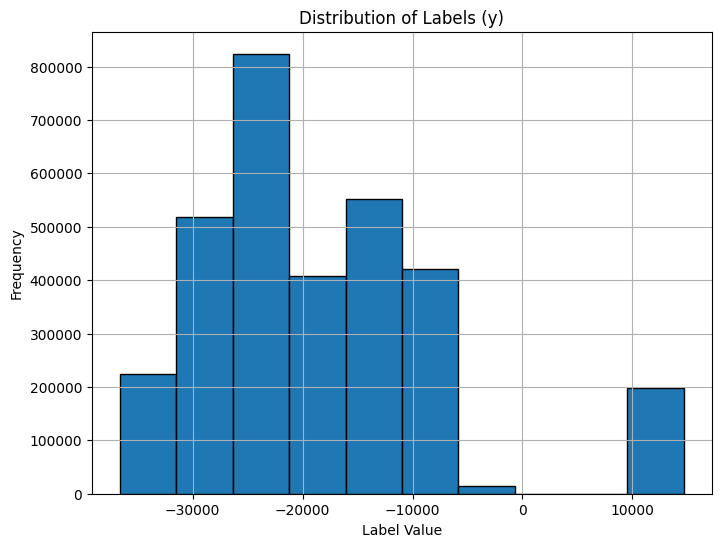

In [10]:
import matplotlib.pyplot as plt

# Visualize the labels y
plt.figure(figsize=(8, 6))
plt.hist(y.flatten(), bins=10, edgecolor='black')
plt.title('Distribution of Labels (y)')
plt.xlabel('Label Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()